### Path Setting

In [4]:
from pathlib import Path

PROJECT_ROOT = Path(r"/Users/yayuntan/Desktop/aps360_project")
DATA_ROOT = PROJECT_ROOT / "data" / "raw"

IMG_DIR = DATA_ROOT / "img"
CATEGORY_IMG_PATH = DATA_ROOT / "list_category_img.txt"
CATEGORY_CLOTH_PATH = DATA_ROOT / "list_category_cloth.txt"
ATTR_IMG_PATH = DATA_ROOT / "list_attr_img.txt"
ATTR_CLOTH_PATH = DATA_ROOT / "list_attr_cloth.txt"
EVAL_PATH = DATA_ROOT / "list_eval_partition.txt"

print(PROJECT_ROOT)
print(IMG_DIR.exists())
print(CATEGORY_IMG_PATH.exists())
print(ATTR_IMG_PATH.exists())
print(EVAL_PATH.exists())

/Users/yayuntan/Desktop/aps360_project
True
True
True
True


### Check Dataset

In [5]:
def preview_file(path, n=12):
    print(f"\n===== {path.name} =====")
    with open(path, "r", encoding="utf-8") as f:
        for i in range(n):
            line = f.readline()
            if not line:
                break
            print(repr(line.rstrip()))

preview_file(CATEGORY_CLOTH_PATH)
preview_file(CATEGORY_IMG_PATH)
preview_file(ATTR_CLOTH_PATH)
preview_file(ATTR_IMG_PATH)
preview_file(EVAL_PATH)


===== list_category_cloth.txt =====
'50'
'category_name  category_type'
'Anorak         1'
'Blazer         1'
'Blouse         1'
'Bomber         1'
'Button-Down    1'
'Cardigan       1'
'Flannel        1'
'Halter         1'
'Henley         1'
'Hoodie         1'

===== list_category_img.txt =====
'289222'
'image_name  category_label'
'img/Sheer_Pleated-Front_Blouse/img_00000001.jpg                        3'
'img/Sheer_Pleated-Front_Blouse/img_00000002.jpg                        3'
'img/Sheer_Pleated-Front_Blouse/img_00000003.jpg                        3'
'img/Sheer_Pleated-Front_Blouse/img_00000004.jpg                        3'
'img/Sheer_Pleated-Front_Blouse/img_00000005.jpg                        3'
'img/Sheer_Pleated-Front_Blouse/img_00000006.jpg                        3'
'img/Sheer_Pleated-Front_Blouse/img_00000007.jpg                        3'
'img/Sheer_Pleated-Front_Blouse/img_00000008.jpg                        3'
'img/Sheer_Pleated-Front_Blouse/img_00000009.jpg                

num images: 289219


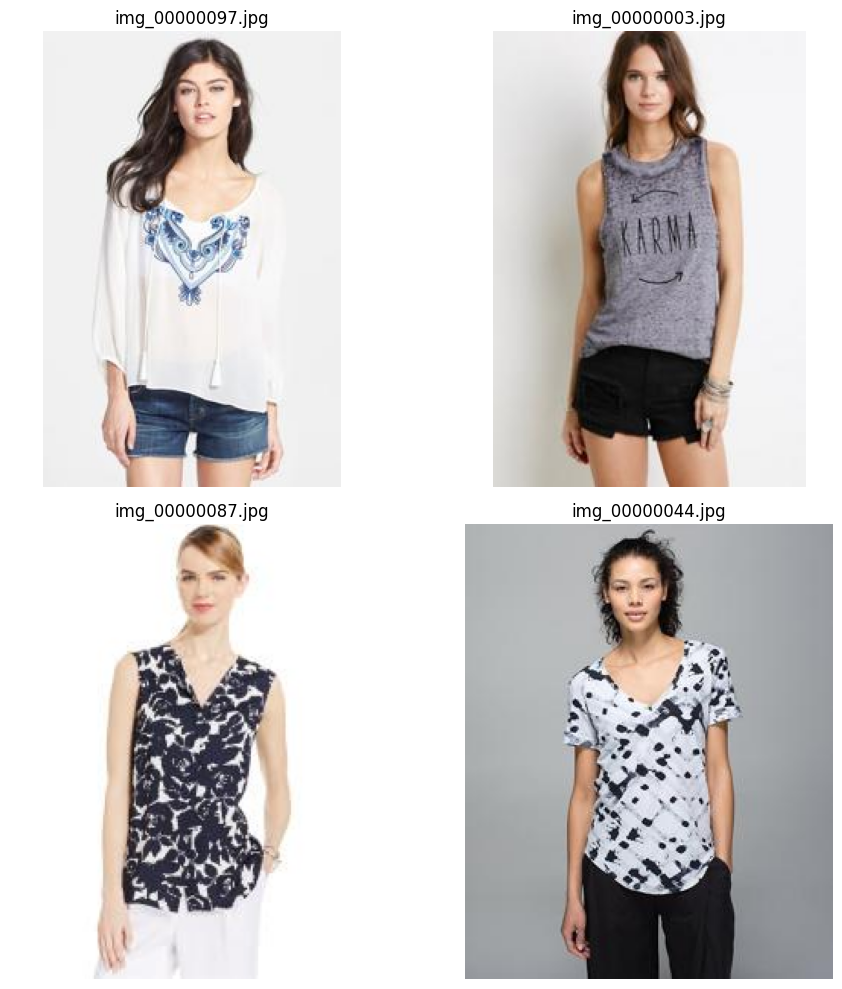

In [6]:
from PIL import Image
import matplotlib.pyplot as plt
import random

all_imgs = list(IMG_DIR.rglob("*.jpg"))
print("num images:", len(all_imgs))

sample_paths = random.sample(all_imgs, 4)

plt.figure(figsize=(10, 10))
for i, path in enumerate(sample_paths, 1):
    img = Image.open(path).convert("RGB")
    plt.subplot(2, 2, i)
    plt.imshow(img)
    plt.title(path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Recategorize 

In [34]:
import pandas as pd

category_cloth = pd.read_csv(
    CATEGORY_CLOTH_PATH,
    sep=r"\s+",
    skiprows=2,
    header=None,
    names=["category_name", "category_type"],
    engine="python"
)

category_cloth["category_id"] = range(1, len(category_cloth) + 1)
category_cloth = category_cloth[["category_id", "category_name", "category_type"]]

print(category_cloth.head(15))
print("num categories:", len(category_cloth))

    category_id category_name  category_type
0             1        Anorak              1
1             2        Blazer              1
2             3        Blouse              1
3             4        Bomber              1
4             5   Button-Down              1
5             6      Cardigan              1
6             7       Flannel              1
7             8        Halter              1
8             9        Henley              1
9            10        Hoodie              1
10           11        Jacket              1
11           12        Jersey              1
12           13         Parka              1
13           14       Peacoat              1
14           15        Poncho              1
num categories: 50


In [35]:
category_img = pd.read_csv(
    CATEGORY_IMG_PATH,
    sep=r"\s+",
    skiprows=2,
    header=None,
    names=["image_name", "category_id"],
    engine="python"
)

eval_df = pd.read_csv(
    EVAL_PATH,
    sep=r"\s+",
    skiprows=2,
    header=None,
    names=["image_name", "split"],
    engine="python"
)

print(category_img.head())
print("num image-category rows:", len(category_img))
print(eval_df.head())
print(eval_df["split"].value_counts())

                                        image_name  category_id
0  img/Sheer_Pleated-Front_Blouse/img_00000001.jpg            3
1  img/Sheer_Pleated-Front_Blouse/img_00000002.jpg            3
2  img/Sheer_Pleated-Front_Blouse/img_00000003.jpg            3
3  img/Sheer_Pleated-Front_Blouse/img_00000004.jpg            3
4  img/Sheer_Pleated-Front_Blouse/img_00000005.jpg            3
num image-category rows: 289222
                                        image_name  split
0  img/Sheer_Pleated-Front_Blouse/img_00000001.jpg  train
1  img/Sheer_Pleated-Front_Blouse/img_00000002.jpg  train
2  img/Sheer_Pleated-Front_Blouse/img_00000003.jpg    val
3  img/Sheer_Pleated-Front_Blouse/img_00000004.jpg  train
4  img/Sheer_Pleated-Front_Blouse/img_00000005.jpg   test
split
train    209222
val       40000
test      40000
Name: count, dtype: int64


In [36]:
df = category_img.merge(category_cloth, on="category_id", how="left")
df = df.merge(eval_df, on="image_name", how="left")

df["image_path"] = df["image_name"].apply(lambda x: str(DATA_ROOT / x))

print(df.head())
print(df.shape)
print(df["split"].value_counts())
print(df["category_name"].nunique())

                                        image_name  category_id category_name  \
0  img/Sheer_Pleated-Front_Blouse/img_00000001.jpg            3        Blouse   
1  img/Sheer_Pleated-Front_Blouse/img_00000002.jpg            3        Blouse   
2  img/Sheer_Pleated-Front_Blouse/img_00000003.jpg            3        Blouse   
3  img/Sheer_Pleated-Front_Blouse/img_00000004.jpg            3        Blouse   
4  img/Sheer_Pleated-Front_Blouse/img_00000005.jpg            3        Blouse   

   category_type  split                                         image_path  
0              1  train  /Users/yayuntan/Desktop/aps360_project/data/ra...  
1              1  train  /Users/yayuntan/Desktop/aps360_project/data/ra...  
2              1    val  /Users/yayuntan/Desktop/aps360_project/data/ra...  
3              1  train  /Users/yayuntan/Desktop/aps360_project/data/ra...  
4              1   test  /Users/yayuntan/Desktop/aps360_project/data/ra...  
(289222, 6)
split
train    209222
val       40000
t

In [37]:
# Define coarse mapping

TOP_CATS = {
    "Blazer", "Blouse", "Button-Down", "Cardigan",
    "Flannel", "Halter", "Henley", "Hoodie", "Jersey",
    "Poncho", "Sweater", "Tank", "Tee", "Top", "Turtleneck"
}

BOTTOM_CATS = {
    "Capris", "Chinos", "Culottes", "Cutoffs", "Gauchos", "Jeans",
    "Jeggings", "Jodhpurs", "Joggers", "Leggings", "Sarong", "Shorts",
    "Skirt", "Sweatpants", "Sweatshorts", "Trunks"
}

DRESS_CATS = {
    "Caftan", "Cape", "Coverup", "Dress", "Jumpsuit", "Kaftan",
    "Kimono", "Nightdress", "Onesie", "Robe", "Romper", "Shirtdress"
}

OUTERWEAR_CATS = {
    "Anorak", "Bomber", "Coat", "Jacket", "Parka", "Peacoat"
}

def map_coarse_category(cat):
    if cat in TOP_CATS:
        return "top"
    if cat in BOTTOM_CATS:
        return "bottom"
    if cat in DRESS_CATS:
        return "dress"
    if cat in OUTERWEAR_CATS:
        return "outerwear"
    return "other"


df["coarse_category"] = df["category_name"].apply(map_coarse_category)
print(df["coarse_category"].value_counts())

coarse_category
top          128000
dress         88430
bottom        58963
outerwear     13829
Name: count, dtype: int64


### Define paring rules

In [38]:
allowed_pairs = {
    "top": {"bottom", "outerwear"},
    "bottom": {"top", "outerwear"},
    "dress": {"outerwear"},
    "outerwear": {"top", "bottom", "dress"},
}

In [39]:
df_1 = df[df["coarse_category"] != "other"].copy()
print(df_1["coarse_category"].value_counts())
print(df_1["split"].value_counts())

coarse_category
top          128000
dress         88430
bottom        58963
outerwear     13829
Name: count, dtype: int64
split
train    209222
val       40000
test      40000
Name: count, dtype: int64


In [40]:
df_1 = df_1.reset_index(drop=True).copy()
df_1["image_id"] = df_1.index

print(df_1.head())

                                        image_name  category_id category_name  \
0  img/Sheer_Pleated-Front_Blouse/img_00000001.jpg            3        Blouse   
1  img/Sheer_Pleated-Front_Blouse/img_00000002.jpg            3        Blouse   
2  img/Sheer_Pleated-Front_Blouse/img_00000003.jpg            3        Blouse   
3  img/Sheer_Pleated-Front_Blouse/img_00000004.jpg            3        Blouse   
4  img/Sheer_Pleated-Front_Blouse/img_00000005.jpg            3        Blouse   

   category_type  split                                         image_path  \
0              1  train  /Users/yayuntan/Desktop/aps360_project/data/ra...   
1              1  train  /Users/yayuntan/Desktop/aps360_project/data/ra...   
2              1    val  /Users/yayuntan/Desktop/aps360_project/data/ra...   
3              1  train  /Users/yayuntan/Desktop/aps360_project/data/ra...   
4              1   test  /Users/yayuntan/Desktop/aps360_project/data/ra...   

  coarse_category  image_id  
0             

In [41]:
from collections import defaultdict

split_cat_to_ids = defaultdict(list)

for _, row in df_1.iterrows():
    split_cat_to_ids[(row["split"], row["coarse_category"])].append(row["image_id"])

for key in list(split_cat_to_ids.keys())[:10]:
    print(key, len(split_cat_to_ids[key]))

('train', 'top') 92531
('val', 'top') 17672
('test', 'top') 17797
('train', 'outerwear') 9991
('val', 'outerwear') 1922
('test', 'outerwear') 1916
('train', 'bottom') 42733
('val', 'bottom') 8151
('test', 'bottom') 8079
('train', 'dress') 63967


In [42]:
attr_img = pd.read_csv(
    ATTR_IMG_PATH,
    sep=r"\s+",
    skiprows=2,
    header=None
)

attr_img = attr_img.rename(columns={0: "image_name"})
attr_cols = [c for c in attr_img.columns if c != "image_name"]

print(attr_img.shape)
print("num attributes:", len(attr_cols))
attr_img.head()

(289222, 1001)
num attributes: 1000


,image_name,1,2,3,4,5,6,7,8,9,...,991,992,993,994,995,996,997,998,999,1000
0,img/Sheer_Pleated-Front_Blouse/img_00000001.jpg,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
1,img/Sheer_Pleated-Front_Blouse/img_00000002.jpg,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
2,img/Sheer_Pleated-Front_Blouse/img_00000003.jpg,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
3,img/Sheer_Pleated-Front_Blouse/img_00000004.jpg,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
4,img/Sheer_Pleated-Front_Blouse/img_00000005.jpg,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


In [43]:
import numpy as np

In [28]:
df_attr = df_1.merge(attr_img, on="image_name", how="inner").copy()

for c in attr_cols:
    df_attr[c] = (df_attr[c] > 0).astype(int)

print(df_attr.shape)
df_attr.head()

def attribute_jaccard(row_a, row_b, attr_cols):
    a = row_a[attr_cols].values.astype(np.int8)
    b = row_b[attr_cols].values.astype(np.int8)

    inter = np.sum((a == 1) & (b == 1))
    union = np.sum((a == 1) | (b == 1))

    if union == 0:
        return 0.0
    return inter / union

(289222, 1008)


### Baseline Model

In [47]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision import models
from tqdm import tqdm
from PIL import Image

In [48]:
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class FashionImageDataset(Dataset):
    def __init__(self, df_items, transform=None):
        self.df_items = df_items.reset_index(drop=True)
        self.transform = transform if transform is not None else image_transform

    def __len__(self):
        return len(self.df_items)

    def __getitem__(self, idx):
        row = self.df_items.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        img = self.transform(img)

        return {
            "image_id": row["image_id"],
            "image": img,
            "coarse_category": row["coarse_category"],
            "split": row["split"],
            "image_name": row["image_name"],
        }

class FrozenResNetEncoder(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()

        self.backbone = backbone
        self.proj = nn.Linear(in_features, embedding_dim)

        for p in self.backbone.parameters():
            p.requires_grad = False

    def forward(self, x):
        feat = self.backbone(x)
        emb = self.proj(feat)
        return emb

In [19]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

dataset_all = FashionImageDataset(df_1)
loader_all = DataLoader(dataset_all, batch_size=32, shuffle=False, num_workers=0)

model = FrozenResNetEncoder(embedding_dim=128).to(device)
model.eval()

all_embs = []
all_ids = []
all_cats = []
all_splits = []
all_names = []

with torch.no_grad():
    for batch in tqdm(loader_all):
        imgs = batch["image"].to(device)
        emb = model(imgs)
        emb = F.normalize(emb, dim=-1)

        all_embs.append(emb.cpu())
        all_ids.extend(batch["image_id"].tolist())
        all_cats.extend(batch["coarse_category"])
        all_splits.extend(batch["split"])
        all_names.extend(batch["image_name"])

all_embs = torch.cat(all_embs, dim=0)
print(all_embs.shape)
print(len(all_ids))

device: mps


100%|██████████| 9039/9039 [14:29<00:00, 10.39it/s]

torch.Size([289222, 128])
289222


In [50]:
emb_df = pd.DataFrame({
    "image_id": all_ids,
    "coarse_category": all_cats,
    "split": all_splits,
    "image_name": all_names,
})

id_to_emb_index = {img_id: i for i, img_id in enumerate(all_ids)}

def retrieve_topk_for_query(query_id, query_cat, split_name, allowed_pairs, k=5):
    if query_cat not in allowed_pairs:
        return []

    target_cats = allowed_pairs[query_cat]

    query_idx = id_to_emb_index[query_id]
    query_emb = all_embs[query_idx]  # [D]

    candidate_mask = (
        (emb_df["split"] == split_name) &
        (emb_df["coarse_category"].isin(target_cats)) &
        (emb_df["image_id"] != query_id)
    )

    candidate_df = emb_df[candidate_mask].copy()
    if len(candidate_df) == 0:
        return []

    candidate_indices = [id_to_emb_index[x] for x in candidate_df["image_id"].tolist()]
    candidate_embs = all_embs[candidate_indices]  # [N, D]

    sims = torch.matmul(candidate_embs, query_emb)  # [N]
    topk_idx = torch.topk(sims, k=min(k, len(candidate_df))).indices.tolist()

    results = candidate_df.iloc[topk_idx].copy()
    results["score"] = [sims[i].item() for i in topk_idx]
    return results

In [51]:
sample_queries = df_1[
    (df_1["split"] == "val") &
    (df_1["coarse_category"].isin(["top", "bottom", "dress", "outerwear"]))].sample(5, random_state=7)

for _, q in sample_queries.iterrows():
    print("\nQUERY:", q["image_name"], "|", q["coarse_category"], "|", q["split"])
    topk = retrieve_topk_for_query(
        query_id=q["image_id"],
        query_cat=q["coarse_category"],
        split_name=q["split"],
        allowed_pairs=allowed_pairs,
        k=5
    )
    print(topk[["image_name", "coarse_category", "score"]])


QUERY: img/V-Neck_Sweater/img_00000017.jpg | top | val
                                               image_name coarse_category  \
130197           img/Pocket_Shirt_Jacket/img_00000072.jpg       outerwear   
105658          img/Hooded_Puffer_Jacket/img_00000076.jpg       outerwear   
8189               img/Zip_Collar_Bomber/img_00000006.jpg       outerwear   
84984   img/EPTM._Quilted_Colorblock_Baseball_Jacket/i...       outerwear   
80004      img/Desert_Trim_Bomber_Jacket/img_00000006.jpg       outerwear   

           score  
130197  0.879366  
105658  0.862193  
8189    0.860181  
84984   0.859477  
80004   0.850702  

QUERY: img/Dotted_Bow_Blouse/img_00000122.jpg | top | val
                                               image_name coarse_category  \
152230        img/Belted_Polka_Dot_Skirt/img_00000029.jpg          bottom   
151424  img/Baroque_Print_Drawstring_Shorts/img_000000...          bottom   
152228        img/Belted_Polka_Dot_Skirt/img_00000027.jpg          bottom   


### Evaluation

In [56]:
random.seed(42)

def build_attr_eval_set(df_items, allowed_pairs, split_name="val", n_negatives=19,
    max_queries_per_cat=1000, candidate_sample_size=300):
    
    eval_rows = []

    split_df = df_items[df_items["split"] == split_name].copy()

    # Catergorize by coarse category
    cat_to_df = {
        cat: split_df[split_df["coarse_category"] == cat].copy()
        for cat in split_df["coarse_category"].unique()
    }

    for query_cat, target_cats in allowed_pairs.items():
        query_pool = split_df[split_df["coarse_category"] == query_cat].copy()

        if len(query_pool) == 0:
            continue

        # Limit the number of queries per category
        if max_queries_per_cat is not None:
            sample_n = min(max_queries_per_cat, len(query_pool))
            query_pool = query_pool.sample(sample_n, random_state=42)

        target_pool = split_df[split_df["coarse_category"].isin(target_cats)].copy()
        if len(target_pool) < n_negatives + 1:
            continue

        for _, q in tqdm(query_pool.iterrows(), total=len(query_pool), desc=f"{split_name}, {query_cat}"):
            q_id = q["image_id"]

            candidate_pool = target_pool[target_pool["image_id"] != q_id].copy()
            if len(candidate_pool) < n_negatives + 1:
                continue

            # Key optimization: sample a smaller candidate set from the large pool
            sample_size = min(candidate_sample_size, len(candidate_pool))
            candidate_pool = candidate_pool.sample(sample_size, random_state=random.randint(0, 100000))

            # Calculate attribute overlap between query and candidates
            q_vec = q[attr_cols].values.astype(np.int8)
            cand_mat = candidate_pool[attr_cols].values.astype(np.int8)

            inter = np.sum((cand_mat == 1) & (q_vec == 1), axis=1)
            union = np.sum((cand_mat == 1) | (q_vec == 1), axis=1)

            # Avoid division by zero
            attr_scores = np.where(union == 0, 0.0, inter / union)

            candidate_pool = candidate_pool.copy()
            candidate_pool["attr_score"] = attr_scores

            # Positive with highest overlap
            candidate_pool = candidate_pool.sort_values("attr_score", ascending=False)
            pos_row = candidate_pool.iloc[0]
            pos_id = pos_row["image_id"]

            # Negative with lowest overlap 
            neg_pool = candidate_pool.iloc[1:].sort_values("attr_score", ascending=True)
            if len(neg_pool) < n_negatives:
                continue

            neg_rows = neg_pool.iloc[:n_negatives]

            candidate_ids = [pos_id] + neg_rows["image_id"].tolist()
            random.shuffle(candidate_ids)

            eval_rows.append({
                "query_id": q_id,
                "query_image_name": q["image_name"],
                "query_cat": query_cat,
                "split": split_name,
                "positive_id": pos_id,
                "positive_cat": pos_row["coarse_category"],
                "positive_attr_score": pos_row["attr_score"],
                "candidate_ids": candidate_ids,
                "positive_index": candidate_ids.index(pos_id),
            })

    return pd.DataFrame(eval_rows)

In [57]:
val_eval_df = build_attr_eval_set(
    df_attr,
    allowed_pairs=allowed_pairs,
    split_name="val",
    n_negatives=19,
    max_queries_per_cat=1000,
    candidate_sample_size=300
)

test_eval_df = build_attr_eval_set(
    df_attr,
    allowed_pairs=allowed_pairs,
    split_name="test",
    n_negatives=19,
    max_queries_per_cat=1000,
    candidate_sample_size=300
)

print("val_eval_df:", val_eval_df.shape)
print("test_eval_df:", test_eval_df.shape)
print(val_eval_df["query_cat"].value_counts())
print(test_eval_df["query_cat"].value_counts())

val, top:   1%|          | 12/1000 [00:00<00:17, 56.94it/s]/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/137571295.py:50: RuntimeWarning: invalid value encountered in divide
  attr_scores = np.where(union == 0, 0.0, inter / union)
val, top:   3%|▎         | 26/1000 [00:00<00:16, 60.14it/s]/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/137571295.py:50: RuntimeWarning: invalid value encountered in divide
  attr_scores = np.where(union == 0, 0.0, inter / union)
/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/137571295.py:50: RuntimeWarning: invalid value encountered in divide
  attr_scores = np.where(union == 0, 0.0, inter / union)
val, top:   3%|▎         | 33/1000 [00:00<00:16, 60.04it/s]/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/137571295.py:50: RuntimeWarning: invalid value encountered in divide
  attr_scores = np.where(union == 0, 0.0, inter / union)
val, top:   8%|▊         | 75/1000 [00:01<00:15, 61.33it/s]

val_eval_df: (4000, 9)
test_eval_df: (4000, 9)
query_cat
top          1000
bottom       1000
dress        1000
outerwear    1000
Name: count, dtype: int64
query_cat
top          1000
bottom       1000
dress        1000
outerwear    1000
Name: count, dtype: int64


In [58]:
def compute_ranking_metrics(eval_df, all_embs, id_to_emb_index, ks=(1, 5)):
    results = []

    for _, row in eval_df.iterrows():
        query_id = row["query_id"]
        candidate_ids = row["candidate_ids"]
        positive_id = row["positive_id"]

        q_idx = id_to_emb_index[query_id]
        q_emb = all_embs[q_idx]

        cand_indices = [id_to_emb_index[cid] for cid in candidate_ids]
        cand_embs = all_embs[cand_indices]

        sims = torch.matmul(cand_embs, q_emb)
        ranked_idx = torch.argsort(sims, descending=True).tolist()
        ranked_candidate_ids = [candidate_ids[i] for i in ranked_idx]

        rank = ranked_candidate_ids.index(positive_id) + 1

        row_result = {
            "query_id": query_id,
            "query_cat": row["query_cat"],
            "positive_cat": row["positive_cat"],
            "rank": rank,
            "mrr_contrib": 1.0 / rank,
        }

        for k in ks:
            row_result[f"hit@{k}"] = 1 if rank <= k else 0

        results.append(row_result)

    results_df = pd.DataFrame(results)

    summary = {
        f"hit@{k}": results_df[f"hit@{k}"].mean()
        for k in ks
    }
    summary["mrr"] = results_df["mrr_contrib"].mean()

    return results_df, summary

In [59]:
val_results_df, val_summary_metrics = compute_ranking_metrics(
    val_eval_df,
    all_embs=all_embs,
    id_to_emb_index=id_to_emb_index,
    ks=(1, 5)
)

test_results_df, test_summary_metrics = compute_ranking_metrics(
    test_eval_df,
    all_embs=all_embs,
    id_to_emb_index=id_to_emb_index,
    ks=(1, 5)
)

print("Validation metrics:", val_summary_metrics)
print("Test metrics:", test_summary_metrics)

Validation metrics: {'hit@1': 0.08375, 'hit@5': 0.31375, 'mrr': 0.21991848285980448}
Test metrics: {'hit@1': 0.072, 'hit@5': 0.29475, 'mrr': 0.20684813680364186}


In [61]:
val_pair_metrics = (
    val_results_df.groupby(["query_cat", "positive_cat"])
    .agg({
        "hit@1": "mean",
        "hit@5": "mean",
        "mrr_contrib": "mean",
        "query_id": "count"
    })
    .rename(columns={
        "mrr_contrib": "mrr",
        "query_id": "num_queries"
    })
    .reset_index()
)

val_pair_metrics

,query_cat,positive_cat,hit@1,hit@5,mrr,num_queries
0,bottom,outerwear,0.060976,0.219512,0.176972,164
1,bottom,top,0.072967,0.296651,0.207398,836
2,dress,outerwear,0.105000,0.363000,0.247434,1000
3,outerwear,bottom,0.059649,0.228070,0.179857,285
4,outerwear,dress,0.066667,0.311111,0.216304,225
5,outerwear,top,0.100000,0.377551,0.245773,490
6,top,bottom,0.070243,0.273308,0.200779,783
7,top,outerwear,0.105991,0.341014,0.240853,217


In [62]:
test_pair_metrics = (
    test_results_df.groupby(["query_cat", "positive_cat"])
    .agg({
        "hit@1": "mean",
        "hit@5": "mean",
        "mrr_contrib": "mean",
        "query_id": "count"
    })
    .rename(columns={
        "mrr_contrib": "mrr",
        "query_id": "num_queries"
    })
    .reset_index()
)

test_pair_metrics

,query_cat,positive_cat,hit@1,hit@5,mrr,num_queries
0,bottom,outerwear,0.025806,0.167742,0.147602,155
1,bottom,top,0.073373,0.288757,0.207354,845
2,dress,outerwear,0.082000,0.299000,0.213202,1000
3,outerwear,bottom,0.067568,0.219595,0.187991,296
4,outerwear,dress,0.071429,0.346939,0.216569,196
5,outerwear,top,0.102362,0.381890,0.253268,508
6,top,bottom,0.048531,0.284802,0.184224,783
7,top,outerwear,0.073733,0.276498,0.207825,217


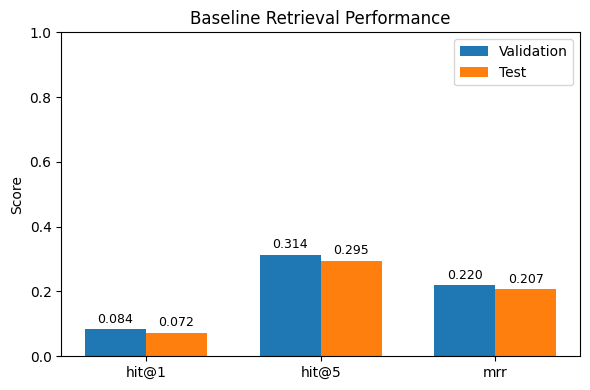

In [79]:
import matplotlib.pyplot as plt

metric_names = ["hit@1", "hit@5", "mrr"]
val_values = [val_summary_metrics[m] for m in metric_names]
test_values = [test_summary_metrics[m] for m in metric_names]

x = range(len(metric_names))
width = 0.35

plt.figure(figsize=(6, 4))
plt.bar([i - width/2 for i in x], val_values, width=width, label="Validation")
plt.bar([i + width/2 for i in x], test_values, width=width, label="Test")

plt.xticks(list(x), metric_names)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Baseline Retrieval Performance")
plt.legend()

for i, v in enumerate(val_values):
    plt.text(i - width/2, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)
for i, v in enumerate(test_values):
    plt.text(i + width/2, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

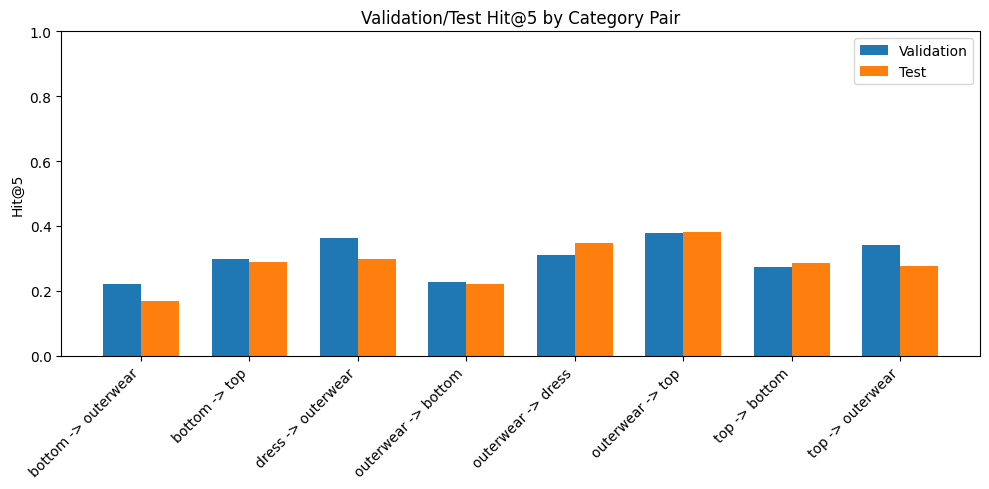

In [67]:
val_pair_metrics["pair_name"] = val_pair_metrics["query_cat"] + " -> " + val_pair_metrics["positive_cat"]
test_pair_metrics["pair_name"] = test_pair_metrics["query_cat"] + " -> " + test_pair_metrics["positive_cat"]

x_val = range(len(val_pair_metrics))
x_test = range(len(test_pair_metrics))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar([i - width/2 for i in x_val], val_pair_metrics["hit@5"], width=width, label="Validation")
plt.bar([i + width/2 for i in x_test], test_pair_metrics["hit@5"], width=width, label="Test")

plt.xticks([i for i in x_val], val_pair_metrics["pair_name"], rotation=45, ha="right")
plt.ylim(0, 1)
plt.ylabel("Hit@5")
plt.title("Validation/Test Hit@5 by Category Pair")
plt.legend()

plt.tight_layout()
plt.show()

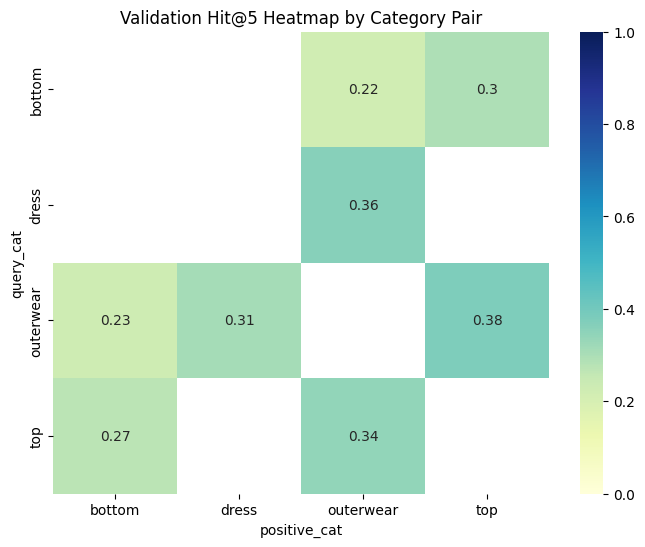

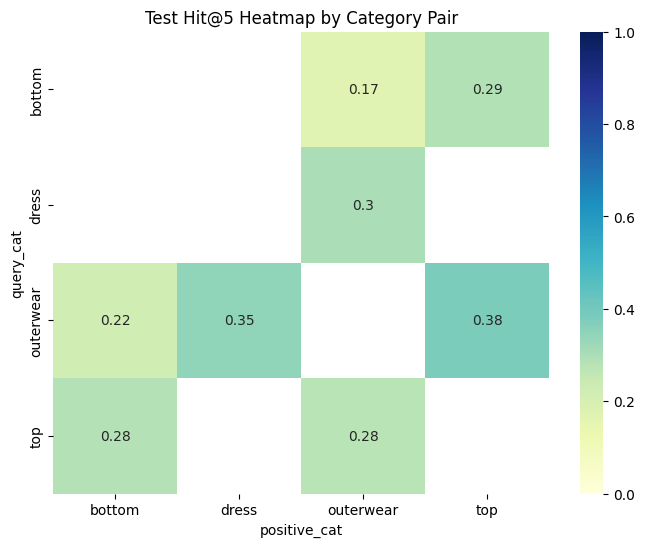

In [78]:
import seaborn as sns

heatmap_val = val_pair_metrics.pivot(index="query_cat", columns="positive_cat", values="hit@5")
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_val, annot=True, cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Validation Hit@5 Heatmap by Category Pair")

heatmap_test = test_pair_metrics.pivot(index="query_cat", columns="positive_cat", values="hit@5")
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_test, annot=True, cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Test Hit@5 Heatmap by Category Pair")


plt.show()

### Primary Model: Fine-tuned ResNet18 + Triplet Loss

In [ ]:
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),          # data augmentation
    transforms.ColorJitter(0.2, 0.2, 0.2),     # data augmentation
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

image_transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class FinetuneResNetEncoder(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()

        self.backbone = backbone
        self.proj = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, embedding_dim)
        )

    def forward(self, x):
        feat = self.backbone(x)
        emb = self.proj(feat)
        return F.normalize(emb, dim=-1)

In [89]:
class TripletFashionDataset(Dataset):
    def __init__(self, df_attr, attr_cols, allowed_pairs, split="train", transform=None,
                 candidate_sample_size=100, top_k_pos=10, top_k_neg=10):
        self.df = df_attr[df_attr["split"] == split].reset_index(drop=True)
        self.attr_cols = attr_cols
        self.allowed_pairs = allowed_pairs
        self.transform = transform or image_transform
        self.candidate_sample_size = candidate_sample_size
        self.top_k_pos = top_k_pos
        self.top_k_neg = top_k_neg

        self.cat_to_indices = defaultdict(list)
        for i, row in self.df.iterrows():
            self.cat_to_indices[row["coarse_category"]].append(i)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        anchor = self.df.iloc[idx]
        anchor_cat = anchor["coarse_category"]

        if anchor_cat not in self.allowed_pairs:
            return self.__getitem__((idx + 1) % len(self))

        target_cat = random.choice(list(self.allowed_pairs[anchor_cat]))
        target_pool_idx = self.cat_to_indices.get(target_cat, [])

        if len(target_pool_idx) < 2:
            return self.__getitem__((idx + 1) % len(self))

        # Sample candidate pool
        sample_size = min(self.candidate_sample_size, len(target_pool_idx))
        sampled_idx = random.sample(target_pool_idx, sample_size)

        # Compute Jaccard scores
        anchor_vec = anchor[self.attr_cols].values.astype(np.int8)
        target_mat = self.df.iloc[sampled_idx][self.attr_cols].values.astype(np.int8)

        inter = np.sum((target_mat == 1) & (anchor_vec == 1), axis=1)
        union = np.sum((target_mat == 1) | (anchor_vec == 1), axis=1)
        scores = np.where(union == 0, 0.0, inter / union)

        sorted_idx = np.argsort(scores)  # ascending

        # Positive: random from top_k_pos
        top_pos = sorted_idx[-self.top_k_pos:]
        pos_local = random.choice(top_pos)

        # Negative: random from bottom top_k_neg
        bot_neg = sorted_idx[:self.top_k_neg]
        neg_local = random.choice(bot_neg)

        anchor_img   = self._load(anchor["image_path"])
        positive_img = self._load(self.df.iloc[sampled_idx[pos_local]]["image_path"])
        negative_img = self._load(self.df.iloc[sampled_idx[neg_local]]["image_path"])

        return anchor_img, positive_img, negative_img

    def _load(self, path):
        img = Image.open(path).convert("RGB")
        return self.transform(img)

# Smaller Dataset
df_attr_small = df_attr.groupby("coarse_category").head(4000).reset_index(drop=True)

train_dataset = TripletFashionDataset(df_attr_small, attr_cols, allowed_pairs, split="train", transform=image_transform,
    candidate_sample_size=100, top_k_pos=10, top_k_neg=10)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

### Training

In [90]:
num_epochs = 5
lr = 1e-4
triplet_margin = 0.3

primary_model = FinetuneResNetEncoder(embedding_dim=128).to(device)
optimizer = torch.optim.Adam(primary_model.parameters(), lr=lr, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
triplet_loss_fn = nn.TripletMarginLoss(margin=triplet_margin, p=2)

train_losses = []

for epoch in range(num_epochs):
    primary_model.train()
    total_loss = 0

    for anchor, positive, negative in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        anchor   = anchor.to(device)
        positive = positive.to(device)
        negative = negative.to(device)

        emb_a = primary_model(anchor)
        emb_p = primary_model(positive)
        emb_n = primary_model(negative)

        loss = triplet_loss_fn(emb_a, emb_p, emb_n)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step()

    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")

Epoch 1/5:   0%|          | 0/364 [00:00<?, ?it/s]/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: RuntimeWarning: invalid value encountered in divide
  scores = np.where(union == 0, 0.0, inter / union)
/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: RuntimeWarning: invalid value encountered in divide
  scores = np.where(union == 0, 0.0, inter / union)
Epoch 1/5:   0%|          | 1/364 [00:00<04:49,  1.25it/s]/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: RuntimeWarning: invalid value encountered in divide
  scores = np.where(union == 0, 0.0, inter / union)
/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: RuntimeWarning: invalid value encountered in divide
  scores = np.where(union == 0, 0.0, inter / union)
Epoch 1/5:   1%|          | 3/364 [00:02<04:22,  1.38it/s]/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: Run

Epoch 01 | Loss: 0.2963 | LR: 1.00e-04


Epoch 2/5:   0%|          | 1/364 [00:00<04:07,  1.47it/s]/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: RuntimeWarning: invalid value encountered in divide
  scores = np.where(union == 0, 0.0, inter / union)
Epoch 2/5:   1%|          | 2/364 [00:01<04:01,  1.50it/s]/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: RuntimeWarning: invalid value encountered in divide
  scores = np.where(union == 0, 0.0, inter / union)
Epoch 2/5:   1%|▏         | 5/364 [00:03<03:58,  1.51it/s]/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: RuntimeWarning: invalid value encountered in divide
  scores = np.where(union == 0, 0.0, inter / union)
/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: RuntimeWarning: invalid value encountered in divide
  scores = np.where(union == 0, 0.0, inter / union)
Epoch 2/5:   2%|▏         | 6/364 [00:04<03:59,  1.49it/s]/var/folders/z0/v53w

Epoch 02 | Loss: 0.2930 | LR: 1.00e-04


Epoch 3/5:   0%|          | 0/364 [00:00<?, ?it/s]/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: RuntimeWarning: invalid value encountered in divide
  scores = np.where(union == 0, 0.0, inter / union)
/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: RuntimeWarning: invalid value encountered in divide
  scores = np.where(union == 0, 0.0, inter / union)
/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: RuntimeWarning: invalid value encountered in divide
  scores = np.where(union == 0, 0.0, inter / union)
/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: RuntimeWarning: invalid value encountered in divide
  scores = np.where(union == 0, 0.0, inter / union)
Epoch 3/5:   1%|          | 2/364 [00:01<04:04,  1.48it/s]/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: RuntimeWarning: invalid value encountered in divide
  scores 

Epoch 03 | Loss: 0.2922 | LR: 5.00e-05


Epoch 4/5:   0%|          | 0/364 [00:00<?, ?it/s]/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: RuntimeWarning: invalid value encountered in divide
  scores = np.where(union == 0, 0.0, inter / union)
/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: RuntimeWarning: invalid value encountered in divide
  scores = np.where(union == 0, 0.0, inter / union)
Epoch 4/5:   0%|          | 1/364 [00:00<03:58,  1.52it/s]/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: RuntimeWarning: invalid value encountered in divide
  scores = np.where(union == 0, 0.0, inter / union)
/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: RuntimeWarning: invalid value encountered in divide
  scores = np.where(union == 0, 0.0, inter / union)
Epoch 4/5:   1%|          | 2/364 [00:01<03:59,  1.51it/s]/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: Run

Epoch 04 | Loss: 0.2861 | LR: 5.00e-05


Epoch 5/5:   1%|          | 3/364 [00:02<04:18,  1.40it/s]/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: RuntimeWarning: invalid value encountered in divide
  scores = np.where(union == 0, 0.0, inter / union)
Epoch 5/5:   1%|▏         | 5/364 [00:03<04:18,  1.39it/s]/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: RuntimeWarning: invalid value encountered in divide
  scores = np.where(union == 0, 0.0, inter / union)
Epoch 5/5:   2%|▏         | 6/364 [00:04<04:13,  1.41it/s]/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: RuntimeWarning: invalid value encountered in divide
  scores = np.where(union == 0, 0.0, inter / union)
Epoch 5/5:   2%|▏         | 7/364 [00:04<04:07,  1.44it/s]/var/folders/z0/v53w_99575jcmx58bkjlccch0000gn/T/ipykernel_12731/2494428861.py:42: RuntimeWarning: invalid value encountered in divide
  scores = np.where(union == 0, 0.0, inter / union)
/var/folders/z0/v53w

Epoch 05 | Loss: 0.2910 | LR: 5.00e-05


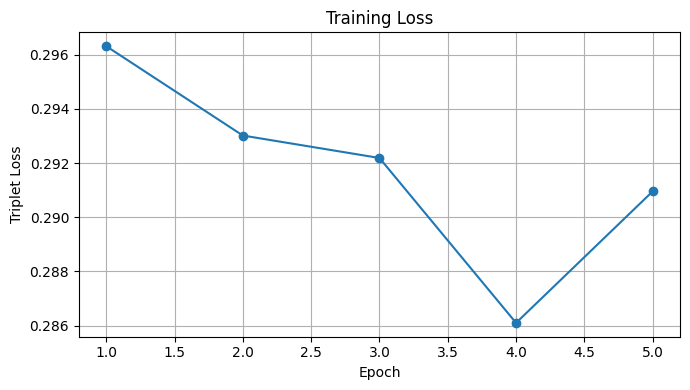

In [91]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, num_epochs + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Triplet Loss")
plt.title("Training Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

### Extract Embeddings

In [92]:
from torch.utils.data import Dataset as _Dataset

class FashionImageDataset(_Dataset):
    def __init__(self, df_items, transform=None):
        self.df_items = df_items.reset_index(drop=True)
        self.transform = transform if transform is not None else image_transform_eval

    def __len__(self):
        return len(self.df_items)

    def __getitem__(self, idx):
        row = self.df_items.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        img = self.transform(img)
        return {
            "image_id": row["image_id"],
            "image": img,
            "coarse_category": row["coarse_category"],
            "split": row["split"],
            "image_name": row["image_name"],
        }


dataset_all = FashionImageDataset(df_1)
loader_all = DataLoader(dataset_all, batch_size=32, shuffle=False, num_workers=0)

primary_model.eval()

all_embs_primary = []
all_ids_primary = []
all_cats_primary = []
all_splits_primary = []
all_names_primary = []

with torch.no_grad():
    for batch in tqdm(loader_all, desc="Extracting embeddings"):
        imgs = batch["image"].to(device)
        emb = primary_model(imgs)
        # already L2-normalized in model forward

        all_embs_primary.append(emb.cpu())
        all_ids_primary.extend(batch["image_id"].tolist())
        all_cats_primary.extend(batch["coarse_category"])
        all_splits_primary.extend(batch["split"])
        all_names_primary.extend(batch["image_name"])

all_embs_primary = torch.cat(all_embs_primary, dim=0)
print("Embeddings shape:", all_embs_primary.shape)

emb_df_primary = pd.DataFrame({
    "image_id": all_ids_primary,
    "coarse_category": all_cats_primary,
    "split": all_splits_primary,
    "image_name": all_names_primary,
})

id_to_emb_index_primary = {img_id: i for i, img_id in enumerate(all_ids_primary)}

Extracting embeddings: 100%|██████████| 9039/9039 [13:55<00:00, 10.82it/s]

Embeddings shape: torch.Size([289222, 128])


### Evaluation

In [94]:
def compute_ranking_metrics(eval_df, all_embs, id_to_emb_index, ks=(1, 5)):
    results = []

    for _, row in eval_df.iterrows():
        query_id = row["query_id"]
        candidate_ids = row["candidate_ids"]
        positive_id = row["positive_id"]

        q_idx = id_to_emb_index[query_id]
        q_emb = all_embs[q_idx]

        cand_indices = [id_to_emb_index[cid] for cid in candidate_ids]
        cand_embs = all_embs[cand_indices]

        sims = torch.matmul(cand_embs, q_emb)
        ranked_idx = torch.argsort(sims, descending=True).tolist()
        ranked_candidate_ids = [candidate_ids[i] for i in ranked_idx]

        rank = ranked_candidate_ids.index(positive_id) + 1

        row_result = {
            "query_id": query_id,
            "query_cat": row["query_cat"],
            "positive_cat": row["positive_cat"],
            "rank": rank,
            "mrr_contrib": 1.0 / rank,
        }

        for k in ks:
            row_result[f"hit@{k}"] = 1 if rank <= k else 0

        results.append(row_result)

    results_df = pd.DataFrame(results)
    summary = {f"hit@{k}": results_df[f"hit@{k}"].mean() for k in ks}
    summary["mrr"] = results_df["mrr_contrib"].mean()

    return results_df, summary


# val_eval_df and test_eval_df come from preprocess.ipynb
val_results_primary, val_metrics_primary = compute_ranking_metrics(
    val_eval_df, all_embs_primary, id_to_emb_index_primary, ks=(1, 5)
)
test_results_primary, test_metrics_primary = compute_ranking_metrics(
    test_eval_df, all_embs_primary, id_to_emb_index_primary, ks=(1, 5)
)

print("Primary Model — Validation: ", val_metrics_primary)
print("Primary Model — Test: ", test_metrics_primary)

Primary Model — Validation:  {'hit@1': 0.1015, 'hit@5': 0.355, 'mrr': 0.24360809753756735}
Primary Model — Test:  {'hit@1': 0.09075, 'hit@5': 0.35375, 'mrr': 0.23591597995013242}


### Baseline vs Primary Comparison

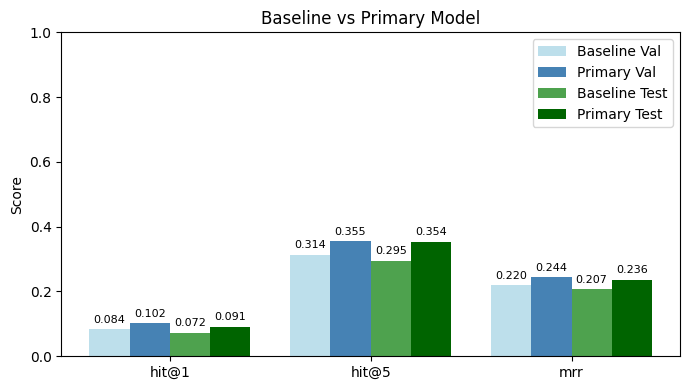

Improvement (val hit@1): +0.018
Improvement (val mrr):   +0.024


In [144]:
metric_names = ["hit@1", "hit@5", "mrr"]

baseline_val  = [val_summary_metrics[m] for m in metric_names]
primary_val   = [val_metrics_primary[m]  for m in metric_names]
baseline_test = [test_summary_metrics[m] for m in metric_names]
primary_test  = [test_metrics_primary[m]  for m in metric_names]

x = np.arange(len(metric_names))
width = 0.2

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(x - 1.5*width, baseline_val,  width, label="Baseline Val",  color="lightblue",  alpha=0.8)
ax.bar(x - 0.5*width, primary_val,   width, label="Primary Val",   color="steelblue",  alpha=1.0)
ax.bar(x + 0.5*width, baseline_test, width, label="Baseline Test", color="forestgreen", alpha=0.8)
ax.bar(x + 1.5*width, primary_test,  width, label="Primary Test",  color="darkgreen", alpha=1.0)

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Baseline vs Primary Model")
ax.legend()

for i, (bv, pv, bt, pt) in enumerate(zip(baseline_val, primary_val, baseline_test, primary_test)):
    ax.text(i - 1.5*width, bv + 0.02, f"{bv:.3f}", ha="center", fontsize=8)
    ax.text(i - 0.5*width, pv + 0.02, f"{pv:.3f}", ha="center", fontsize=8)
    ax.text(i + 0.5*width, bt + 0.02, f"{bt:.3f}", ha="center", fontsize=8)
    ax.text(i + 1.5*width, pt + 0.02, f"{pt:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

print("Improvement (val hit@1):",
      f"{val_metrics_primary['hit@1'] - val_summary_metrics['hit@1']:+.3f}")
print("Improvement (val mrr):  ",
      f"{val_metrics_primary['mrr'] - val_summary_metrics['mrr']:+.3f}")

In [142]:
torch.save(primary_model.state_dict(), "primary_model_best.pth")
print("Model saved to primary_model_best.pth")

Model saved to primary_model_best.pth
